# Summary
WHH model (Dirty limit) fitting / curve-plotting methods validation.
Two methods---`mpmath.nsum(..., method="r+s+e")` and `polygamma`---are consistent for test cases.  
Implemented `polygamma` method was about 1000 times faster than the `nsum`.

* Fitting Consistency
    * residual (LHS-RHS) $<2\times 10^{-13}$
    * Fitting parameters $\alpha$ and $\lambda_{SO}$ are not consistent: possibly because of the residual function $R = (\textrm{LHS}-\textrm{RHS})^2$ is mostly invariant over the large valley in the $(\alpha, \lambda)$ space.
    
    $$R(\alpha + c_1 \epsilon, \lambda + c_2 \epsilon) \sim R(\alpha, \lambda)$$

    where $c_1, c_2$ are constant real numbers.  
    In particular, parameters are likely diverging for `TS4`: $\alpha \gg 1$ and $\lambda \gg 1$.

* Consistency of curve plot : $\Delta H_{c2} < 10^{-12}$
* Default `mpmath.nsum` (with `method="r+s"`) stops too early if the modulus $|q| \gg 1$ 
    * where $q = \frac{\sqrt{\lambda_{SO}^2/4-\left(\alpha \bar{h}\right)^2}}{t}$

In [1]:
# Neccessary imports

import numpy as np
from scipy.optimize import least_squares
import mpmath as mp
import pandas as pd

from whh import WHHModel
print(f"{np.__version__=}\n{mp.__version__=}\n{pd.__version__=}")

np.__version__='2.5.0'
mp.__version__='1.4.1'
pd.__version__='3.0.3'


# Difference of summation methods
In some cases, the default `mpmath.nsum` stops too early, underestimating residual.  
For example, Mayoh et al. (2017) reported properties of `Re6Zr` as  
$slope = 2.44, T_c=6.75\pm 0.05, \alpha=1.31, \lambda_{SO}=18\pm5$

## Alternate methods
First, I have tried to use `mpmath.nsum` but was too slow to converge

***RHS for each methods***  
1. ***polygamma***: polygamma closed form, current default. `whh.WHHModel._brace_term_polygamma`
1. ***nsum_rs***: `mpmath.nsum` with default method, `Richardson + Shanks`
1. ***nsum_rse***: `mpmath.nsum(..., method="r+s+e")`
1. ***explicit 2e6***: explicit sum $2\times \sum_{k=0}^{2\times 10^6}...$, using `mpmath.fsum`

Difference of `polygamma` and `mpmath` methods:

|Tc(K)|nsum_rs|nsum_rse|explicit 2e6|
|----|----|----|----|
|0.00675|0.0111939|-1.77636e-15|2.38803e-05|
|0.0675|2.27707e-09|-3.9968e-15|2.38752e-06|
|0.675|4.44089e-16|4.44089e-16|2.34102e-07|
|6.6825|2.68882e-16|2.68882e-16|3.56067e-10|

## Reference
**[Mayoh et al. (2017)](https://doi.org/10.1103/PhysRevB.96.064521)** Mayoh, D. A., Barker, J. A. T., Singh, R. P., Balakrishnan, G., Paul, D. McK., & Lees, M. R. (2017). Superconducting and normal-state properties of the noncentrosymmetric superconductor Re 6 Zr. Physical Review B, 96(6), 064521.

In [2]:
mayoh_params = dict(
    slope=2.44,
    t_c=6.75,
    alpha=1.31,
    l_so=18
)
m=WHHModel(**mayoh_params)

test_diffs = []
test_t=[0.001, 0.01, 0.1, 0.99]
for t in test_t:
    raw_t = t*mayoh_params['t_c']
    _, h = m.curve([t,], return_reduced=False)

    bar_h=m.reduced_field(h[0], 1.4, 5.0)
    def summand(nu):
        return m._brace_term(nu, bar_h, raw_t, mayoh_params['alpha'], mayoh_params['l_so'])
    partial_explicit2e6 = 2*mp.fsum([summand(n) for n in range(2_000_000)])
    rhs_pg = m._brace_term_polygamma(bar_h, raw_t, mayoh_params['alpha'], mayoh_params['l_so'], on_seam=False)

    rhs_diff_from_polygamma = dict(
        t=raw_t,
        nsum_rs = rhs_pg-mp.nsum(summand, [-mp.inf, mp.inf], method='r+s'),
        nsum_rse = rhs_pg-mp.nsum(summand, [-mp.inf, mp.inf], method='r+s+e'),
        explicit_2e6=rhs_pg-partial_explicit2e6,
    )
    test_diffs.append({k:f'{v:g}' for k, v in rhs_diff_from_polygamma.items()})

pd.DataFrame.from_dict(test_diffs)

,t,nsum_rs,nsum_rse,explicit_2e6
0,0.00675,0.0111939,-1.77636e-15,2.38803e-05
1,0.0675,2.27707e-09,-3.9968e-15,2.38752e-06
2,0.675,4.44089e-16,4.44089e-16,2.34102e-07
3,6.6825,2.68882e-16,2.68882e-16,3.56067e-10


## Test data
Kim et al. 2025 Figure S9 and Table S1

In [3]:
data_df = pd.read_csv("kim_data.csv")
meta_df = pd.read_csv("kim_meta.csv", index_col='exp_name')
meta_df=meta_df.rename(columns={'t_c_mj':'t_c', 'h_orb_emp':'h_orb'})
experiments = meta_df.index.tolist()
exp_idx0 = 0
for idx, row in meta_df.iterrows():
    assert pd.notna(data_df.loc[exp_idx0, 'exp_name'])
    data_df.loc[exp_idx0:exp_idx0+row['num_point']-1, 'exp_name']=data_df.loc[exp_idx0, 'exp_name']
    exp_idx0=exp_idx0+row['num_point']

data_df=data_df.rename(columns={'T(K)':'t','Hc2(T)':'field'})

# Validation

In [4]:
init_params = dict(alpha=1.0, l_so=0.01, slope=1.0, t_c=5.0)
m = WHHModel(**init_params)
m_nsum = WHHModel(**init_params, summation='mpmath_nsum')

ei = experiments[3]

fit = ["alpha", "l_so"]
fixed = ['slope', 't_c']
misc_from_csv = ['h_orb',]

res={}
# test some initial parameters set
init_a_l = {
    "a0l0":(0.01, 0.01),
    "a0l1":(0.01, 1.0),
    "a1l1":(1.0, 1.0),
    "a1l0":(1.0, 0.01),
}

## Execution Time
Fit $(\alpha,\lambda_{SO})$ for 4 initial parameter pairs over 4 experiments with ~10 Hc2-T datapoints  
Not exact benchmark but just the `Execution Time` of the jupyter notebook.
* `polygamma` (new default): ~200 ms
* `mpmath.nsum`: ~1 minutes
* `mpmath.nsum` with `method="r+s+e"`: ~4 minutes

In [5]:
# series summation by polygamma function (new default)
results_pg=[]

for ei in experiments:
    measured_df = data_df[data_df['exp_name']==ei]
    t_obs = measured_df['t']
    h_obs = measured_df['field']
    fixed_params = meta_df[fixed].loc[ei].to_dict()
    misc_params = meta_df[misc_from_csv].loc[ei].to_dict()
    
    model = WHHModel(**fixed_params)
    resid, x0 = model.make_residual(t_obs, h_obs, fit=fit)
    
    for p0, (a0, l0) in init_a_l.items():
        res=least_squares(resid, [a0, l0], bounds=((0, 0), (20, 400)), xtol=1e-12, gtol=1e-12)
        results_pg.append(dict(
            exp_id=ei,
            init_params_name=p0,
            a0=a0,
            l0=l0,
            alpha = res.x[0],
            l_so = res.x[1],
            cost = res.cost,
            status = res.status,
            **misc_params,
            **fixed_params
            ))
pg_df = pd.DataFrame.from_dict(results_pg)
pg_df

,exp_id,init_params_name,a0,l0,alpha,l_so,cost,status,h_orb,slope,t_c
0,TS1,a0l0,0.01,0.01,0.767764,1.337661e-01,0.001097,2,5.22,-1.4,5.4
1,TS1,a0l1,0.01,1.00,0.767778,1.337878e-01,0.001097,2,5.22,-1.4,5.4
2,TS1,a1l1,1.00,1.00,0.767774,1.337812e-01,0.001097,2,5.22,-1.4,5.4
3,TS1,a1l0,1.00,0.01,0.767777,1.337860e-01,0.001097,2,5.22,-1.4,5.4
4,TS2,a0l0,0.01,0.01,0.578303,9.253580e-16,0.000290,2,5.31,-1.4,5.5
5,TS2,a0l1,0.01,1.00,0.578303,4.333722e-15,0.000290,2,5.31,-1.4,5.5
6,TS2,a1l1,1.00,1.00,0.578303,4.023691e-15,0.000290,2,5.31,-1.4,5.5
7,TS2,a1l0,1.00,0.01,0.578303,3.416312e-15,0.000290,2,5.31,-1.4,5.5
8,TS3,a0l0,0.01,0.01,0.582207,2.796516e-15,0.000894,2,4.94,-1.4,5.1
9,TS3,a0l1,0.01,1.00,0.582207,9.721130e-15,0.000894,2,4.94,-1.4,5.1


In [6]:
# mpmath summation
results_mn=[]

for ei in experiments:
    measured_df = data_df[data_df['exp_name']==ei]
    t_obs = measured_df['t']
    h_obs = measured_df['field']
    fixed_params = meta_df[fixed].loc[ei].to_dict()
    misc_params = meta_df[misc_from_csv].loc[ei].to_dict()
    
    model = WHHModel(**fixed_params, summation='mpmath_nsum')
    resid, x0 = model.make_residual(t_obs, h_obs, fit=fit)
    
    for p0, (a0, l0) in init_a_l.items():
        res=least_squares(resid, [a0, l0], bounds=((0, 0), (20, 400)), xtol=1e-12, gtol=1e-12)
        results_mn.append(dict(
            exp_id=ei,
            init_params_name=p0,
            a0=a0,
            l0=l0,
            alpha = res.x[0],
            l_so = res.x[1],
            cost = res.cost,
            status = res.status,
            **misc_params,
            **fixed_params
            ))
mn_df = pd.DataFrame.from_dict(results_mn)
mn_df


,exp_id,init_params_name,a0,l0,alpha,l_so,cost,status,h_orb,slope,t_c
0,TS1,a0l0,0.01,0.01,0.767767,1.337694e-01,0.001097,2,5.22,-1.4,5.4
1,TS1,a0l1,0.01,1.00,0.767779,1.337890e-01,0.001097,2,5.22,-1.4,5.4
2,TS1,a1l1,1.00,1.00,0.767773,1.337803e-01,0.001097,2,5.22,-1.4,5.4
3,TS1,a1l0,1.00,0.01,0.767777,1.337856e-01,0.001097,2,5.22,-1.4,5.4
4,TS2,a0l0,0.01,0.01,0.578303,9.253750e-16,0.000290,2,5.31,-1.4,5.5
5,TS2,a0l1,0.01,1.00,0.578303,4.327042e-15,0.000290,2,5.31,-1.4,5.5
6,TS2,a1l1,1.00,1.00,0.578303,4.029296e-15,0.000290,2,5.31,-1.4,5.5
7,TS2,a1l0,1.00,0.01,0.578303,3.412955e-15,0.000290,2,5.31,-1.4,5.5
8,TS3,a0l0,0.01,0.01,0.582207,2.773274e-15,0.000894,2,4.94,-1.4,5.1
9,TS3,a0l1,0.01,1.00,0.582207,1.013319e-14,0.000894,2,4.94,-1.4,5.1


## Consistency of fitting: residual value
Fitted parameters are not consistent, maybe due the existence of the wide valley.
But residual itself is consistent.

In [7]:
alpha_diff = max(abs(mn_df['alpha'].to_numpy()-pg_df['alpha'].to_numpy()))
lambda_diff = max(abs(mn_df['l_so'].to_numpy()-pg_df['l_so'].to_numpy()))
print(f'{alpha_diff=:g}, {lambda_diff=:g}')

alpha_diff=6.83359, lambda_diff=297.091


In [8]:
def comparison_dict(row, ei, p0, alpha, l_so, h_obs, fixed_params, res_pg, res_mn, on_seam_field):
    return dict(
        exp_id=ei,
        init_params_name=p0,
        a0=row['a0'],
        l0=row['l0'],
        alpha=alpha,
        l_so=l_so,
        max_res = max(max(abs(res_mn)), max(abs(res_pg))),
        max_res_diff = max(abs(res_mn-res_pg)),
        on_seam_field=on_seam_field,
        init_on_seam_field =  (-row['l0']/(2*row['a0']))*fixed_params['t_c']*fixed_params['slope']/(4/np.pi**2),
        on_seam_nearest_field_diff = min(abs(h_obs-on_seam_field))
        )

def compare_fit(row):
    ei = row['exp_id']
    p0 = row['init_params_name']
    alpha = row['alpha'] # fitting results
    l_so = row['l_so'] # fitting results

    measured_df = data_df[data_df['exp_name']==ei]
    t_obs = measured_df['t']
    h_obs = measured_df['field']
    fixed_params = meta_df[fixed].loc[ei].to_dict()
    misc_params = meta_df[misc_from_csv].loc[ei].to_dict()

    model = WHHModel(**fixed_params)

    resid, _ = model.make_residual(t_obs, h_obs, fit=fit)

    model_mpmath = WHHModel(**fixed_params, summation='mpmath_nsum')
    resid_mn, _ = model_mpmath.make_residual(t_obs, h_obs, fit=fit)

    res_pg = resid((alpha, l_so))
    res_mn = resid_mn((alpha, l_so))
    on_seam_field = (-l_so/(2*alpha))*fixed_params['t_c']*fixed_params['slope']/(4/np.pi**2)
    return ei,p0,alpha,l_so,h_obs,fixed_params,res_pg,res_mn,on_seam_field

results_mn_params=[]

for idx, row in mn_df.iterrows():
    ei, p0, alpha, l_so, h_obs, fixed_params, res_pg, res_mn, on_seam_field = compare_fit(row)

    results_mn_params.append(comparison_dict(row, ei, p0, alpha, l_so, h_obs, fixed_params, res_pg, res_mn, on_seam_field))
pd.DataFrame.from_dict(results_mn_params)

,exp_id,init_params_name,a0,l0,alpha,l_so,max_res,max_res_diff,on_seam_field,init_on_seam_field,on_seam_nearest_field_diff
0,TS1,a0l0,0.01,0.01,0.767767,1.337694e-01,0.035371,4.884981e-15,1.625022e+00,9.326776,0.097998
1,TS1,a0l1,0.01,1.00,0.767779,1.337890e-01,0.035371,7.605028e-15,1.625233e+00,932.677616,0.097787
2,TS1,a1l1,1.00,1.00,0.767773,1.337803e-01,0.035371,3.441691e-15,1.625140e+00,9.326776,0.097880
3,TS1,a1l0,1.00,0.01,0.767777,1.337856e-01,0.035371,5.717649e-15,1.625197e+00,0.093268,0.097823
4,TS2,a0l0,0.01,0.01,0.578303,9.253750e-16,0.014829,6.383782e-15,1.520067e-14,9.499494,0.588060
5,TS2,a0l1,0.01,1.00,0.578303,4.327042e-15,0.014829,6.938894e-15,7.107813e-14,949.949424,0.588060
6,TS2,a1l1,1.00,1.00,0.578303,4.029296e-15,0.014829,7.563394e-15,6.618721e-14,9.499494,0.588060
7,TS2,a1l0,1.00,0.01,0.578303,3.412955e-15,0.014829,5.634382e-15,5.606288e-14,0.094995,0.588060
8,TS3,a0l0,0.01,0.01,0.582207,2.773274e-15,0.024881,6.050715e-15,4.195886e-14,8.808622,0.170180
9,TS3,a0l1,0.01,1.00,0.582207,1.013319e-14,0.024881,6.945833e-15,1.533123e-13,880.862193,0.170180


In [9]:
results_pg_params=[]

for idx, row in pg_df.iterrows():
    ei, p0, alpha, l_so, h_obs, fixed_params, res_pg, res_mn, on_seam_field = compare_fit(row)
    results_pg_params.append(comparison_dict(row, ei, p0, alpha, l_so, h_obs, fixed_params, res_pg, res_mn, on_seam_field))

pd.DataFrame.from_dict(results_pg_params)

,exp_id,init_params_name,a0,l0,alpha,l_so,max_res,max_res_diff,on_seam_field,init_on_seam_field,on_seam_nearest_field_diff
0,TS1,a0l0,0.01,0.01,0.767764,1.337661e-01,0.035371,4.662937e-15,1.624986e+00,9.326776,0.098034
1,TS1,a0l1,0.01,1.00,0.767778,1.337878e-01,0.035371,6.328271e-15,1.625220e+00,932.677616,0.097800
2,TS1,a1l1,1.00,1.00,0.767774,1.337812e-01,0.035371,6.106227e-15,1.625149e+00,9.326776,0.097871
3,TS1,a1l0,1.00,0.01,0.767777,1.337860e-01,0.035371,3.663736e-15,1.625201e+00,0.093268,0.097819
4,TS2,a0l0,0.01,0.01,0.578303,9.253580e-16,0.014829,6.050715e-15,1.520039e-14,9.499494,0.588060
5,TS2,a0l1,0.01,1.00,0.578303,4.333722e-15,0.014829,7.702172e-15,7.118787e-14,949.949424,0.588060
6,TS2,a1l1,1.00,1.00,0.578303,4.023691e-15,0.014829,6.480927e-15,6.609515e-14,9.499494,0.588060
7,TS2,a1l0,1.00,0.01,0.578303,3.416312e-15,0.014829,6.966649e-15,5.611803e-14,0.094995,0.588060
8,TS3,a0l0,0.01,0.01,0.582207,2.796516e-15,0.024881,5.884182e-15,4.231051e-14,8.808622,0.170180
9,TS3,a0l1,0.01,1.00,0.582207,9.721130e-15,0.024881,7.483597e-15,1.470780e-13,880.862193,0.170180


## Consistency of curve plots
When $T \rightarrow 0$, `mpmath.nsum` by default () shows relatively large error $>0.0001$

In [10]:
# grid_search_df: based on the fitted results, plot WHH model graphs.
from typing import Literal
def plot_fitted(n, res_df, data_df, meta_df, use_fixed, ei, max_alpha, id, fit=None, fixed=None, summation:Literal["mpmath_nsum", "polygamma"]="polygamma"):
    grid = np.linspace(0.03, 0.99, n)
    result = res_df[(res_df['exp_id']==ei) & (res_df['init_params_name']==id)].iloc[0].to_dict()
    fitted_params={fp:result[fp] for fp in fit}
    max_alpha = max(max_alpha, fitted_params['alpha'])
    fixed_params={fp:result[fp] for fp in fixed}
    m = WHHModel(**fitted_params, **fixed_params, summation=summation)
    h_orb = result['h_orb']
    measured_df = data_df[data_df['exp_name']==ei]
    t_obs = measured_df['t'].to_numpy()
    h_obs = measured_df['field'].to_numpy()
    _, hh = m.curve(grid, h_orb=h_orb, return_reduced=False)
    load_measuared0=meta_df[use_fixed].loc[ei].to_dict()
    out_df=pd.DataFrame.from_dict(dict(
            exp_name=f'Fit_{ei}',
            p0_name=result['init_params_name'],
            type='WHH',
            t=grid*fixed_params['t_c'],
            reduced_t=grid,
            field=hh,
            reduced_h=hh/h_orb,
            r2_score=m.score(t_obs/fixed_params['t_c'], h_obs, **fitted_params)['r2'],
            cost = result['cost'],
            **load_measuared0,
            **fitted_params)
        )
    
    return max_alpha,grid,fixed_params,m,h_orb,t_obs,h_obs,load_measuared0,out_df

def plot_reference(ei, grid, p0_name, t_c, alpha, l_so, m, h_orb, t_obs, h_obs, load_measuared0):
    _, hh = m.curve(grid, h_orb=h_orb, alpha=alpha, l_so=l_so, return_reduced=False)
    orbital_limit_df = pd.DataFrame.from_dict(dict(
            exp_name=f'Fit_{ei}',
            p0_name=p0_name,
            type='WHH',
            t=grid*t_c,
            reduced_t=grid,
            field=hh,
            reduced_h=hh/h_orb,
            r2_score=m.score(t_obs/t_c, h_obs, alpha=alpha, l_so=l_so)['r2'],
            **load_measuared0,
            alpha=alpha,
            l_so=l_so)
        )
        
    return orbital_limit_df

In [11]:
n=5

use_fixed = ['slope', 't_c', 'h_orb']
list_grid_search_df = []
for ei in experiments:
    max_alpha = 0.0
    for id, (a0, l0) in init_a_l.items():
        max_alpha, grid, fixed_params, m, h_orb, t_obs, h_obs, load_measuared0, out_df = plot_fitted(n, mn_df, data_df, meta_df, use_fixed, ei, max_alpha, id, fit=fit, fixed=fixed, summation='polygamma')
        list_grid_search_df.append(out_df)

    orbital_limit_df = plot_reference(ei, grid, 'ref_a0l0', fixed_params['t_c'], 0.0, 0.0, m, h_orb, t_obs, h_obs, load_measuared0)
    list_grid_search_df.append(orbital_limit_df)
    
    max_pauli_df = plot_reference(ei, grid, 'ref_afl0', fixed_params['t_c'], max_alpha, 0.0, m, h_orb, t_obs, h_obs, load_measuared0)
    list_grid_search_df.append(max_pauli_df)

grid_search_df = pd.concat(list_grid_search_df, ignore_index=True)

Text(0, 0.5, 'Hc2(0)(T)')

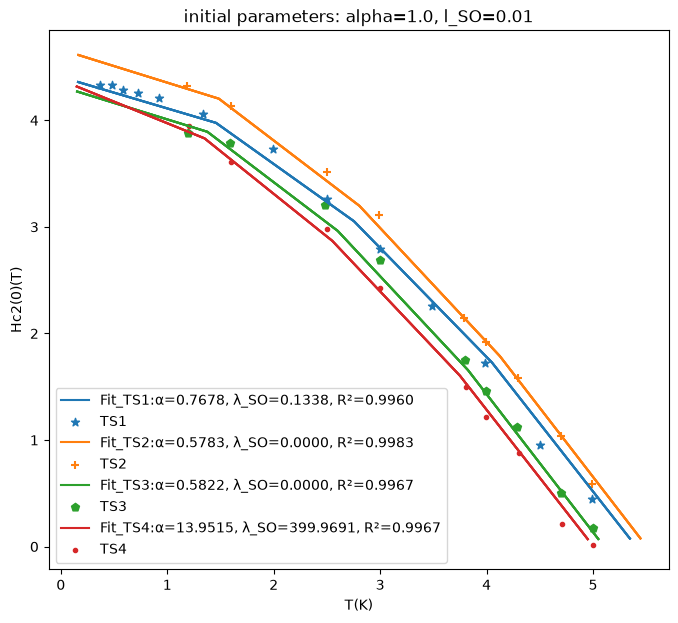

In [12]:
import matplotlib.pyplot as plt
# matplotlib
symbols=['*', '+', 'p', '.', '1','o','p','s','x']
plt.figure(figsize=(8, 7))
for i, ei in enumerate(experiments):
    exp_name = 'Fit_'+ei
    exp_df = data_df[data_df['exp_name']==ei]

    for j, p0_id in enumerate(init_a_l): #use keys only
        fit_df = grid_search_df[(grid_search_df['exp_name']==exp_name) & (grid_search_df['p0_name']==p0_id)]
        result = mn_df[(mn_df['exp_id']==ei) & (mn_df['init_params_name']==p0_id)].iloc[0].to_dict()
        fitted_params={fp:result[fp] for fp in fit}
        fixed_params={fp:result[fp] for fp in fixed}
        if j==3:
            label=f"{exp_name}:α={fitted_params['alpha']:.4f}, λ_SO={fitted_params['l_so']:.4f}, R²={fit_df['r2_score'].tolist()[0]:.4f}"
        else:
            label=None
        plt.plot(fit_df['t'], fit_df['field'], f'C{i}', label=label)
    plt.scatter(exp_df['t'], exp_df['field'], c=f'C{i}', marker=symbols[i], label=f"{ei}")
plt.title('initial parameters: alpha=1.0, l_SO=0.01')
plt.legend()
plt.xlabel('T(K)')
plt.ylabel('Hc2(0)(T)')

Text(0, 0.5, 'Hc2(0)(T)')

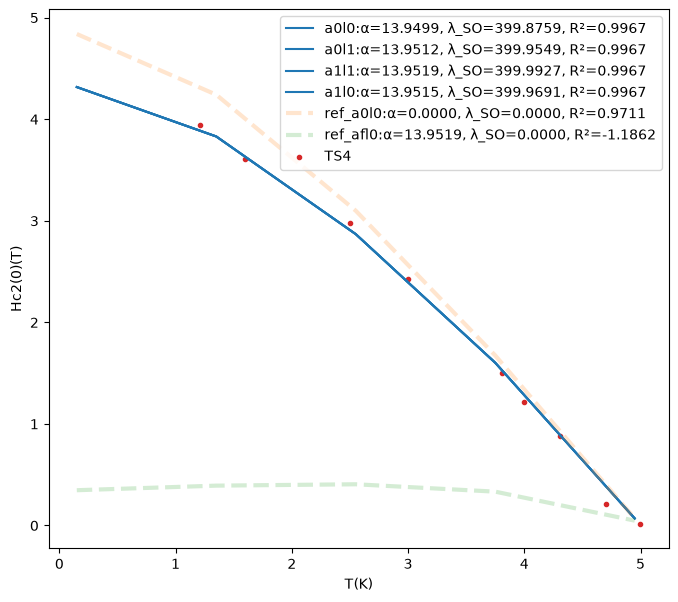

In [13]:
import matplotlib.pyplot as plt
# matplotlib
symbols=['*', '+', 'p', '.', '1','o','p','s','x']
plt.figure(figsize=(8, 7))

# plot for experiments0, TS1
ci=0 #color
ei = experiments[3]

exp_name = 'Fit_'+ei
exp_df = data_df[data_df['exp_name']==ei]

for j, p0_id in enumerate(init_a_l): #use keys only
    fit_df = grid_search_df[(grid_search_df['exp_name']==exp_name) & (grid_search_df['p0_name']==p0_id)]
    result = mn_df[(mn_df['exp_id']==ei) & (mn_df['init_params_name']==p0_id)].iloc[0].to_dict()
    fitted_params={fp:result[fp] for fp in fit}
    fixed_params={fp:result[fp] for fp in fixed}
    label=f"{p0_id}:α={fitted_params['alpha']:.4f}, λ_SO={fitted_params['l_so']:.4f}, R²={fit_df['r2_score'].tolist()[0]:.4f}"
    plt.plot(fit_df['t'], fit_df['field'], f'C{ci}', label=label)
ci+=1

# reference lines
for j, p0_id in enumerate(['ref_a0l0', 'ref_afl0']):
    fit_meta = grid_search_df[(grid_search_df['exp_name']==exp_name) & (grid_search_df['p0_name']==p0_id)].iloc[0].to_dict()
    fit_df = grid_search_df[(grid_search_df['exp_name']==exp_name) & (grid_search_df['p0_name']==p0_id)]
    label=f"{p0_id}:α={fit_meta['alpha']:.4f}, λ_SO={fit_meta['l_so']:.4f}, R²={fit_meta['r2_score']:.4f}"
    plt.plot(fit_df['t'], fit_df['field'], f'C{ci}--', label=label, linewidth=3, alpha=0.2)
    ci+=1

plt.scatter(exp_df['t'], exp_df['field'], c=f'C{ci}', marker=symbols[ci], label=f"{ei}")
plt.legend()
plt.xlabel('T(K)')
plt.ylabel('Hc2(0)(T)')

In [14]:
# mpmath.nsum
# grid_search_df: based on the fitted results, plot WHH model graphs.
n=5
use_fixed = ['slope', 't_c', 'h_orb']
list_grid_search_df = []
for ei in experiments:
    for id, (a0, l0) in init_a_l.items():
        max_alpha, grid, fixed_params, m, h_orb, t_obs, h_obs, load_measuared0, out_df = plot_fitted(n, mn_df, data_df, meta_df, use_fixed, ei, 0, id, fit=fit, fixed=fixed, summation='mpmath_nsum')
        list_grid_search_df.append(out_df)

grid_search_mpmath_df = pd.concat(list_grid_search_df, ignore_index=True)

In [15]:
for ei in experiments:
    exp_name = 'Fit_'+ei
    for id, (a0, l0) in init_a_l.items():
        result = mn_df[(mn_df['exp_id']==ei) & (mn_df['init_params_name']==id)].iloc[0].to_dict()
        fit_df = grid_search_df[(grid_search_df['exp_name']==exp_name) & (grid_search_df['p0_name']==id)]
        fit_mpmath_df = grid_search_mpmath_df[(grid_search_mpmath_df['exp_name']==exp_name) & (grid_search_mpmath_df['p0_name']==id)]
        field_diff = fit_mpmath_df['field'].to_numpy()-fit_df['field'].to_numpy()
        print(f"{max(field_diff)=:g} for {exp_name}_{id}")

max(field_diff)=7.10543e-15 for Fit_TS1_a0l0
max(field_diff)=2.3731e-15 for Fit_TS1_a0l1
max(field_diff)=1.42109e-14 for Fit_TS1_a1l1
max(field_diff)=7.54952e-15 for Fit_TS1_a1l0
max(field_diff)=5.32907e-15 for Fit_TS2_a0l0
max(field_diff)=2.90878e-14 for Fit_TS2_a0l1
max(field_diff)=5.96329e-14 for Fit_TS2_a1l1
max(field_diff)=2.4647e-14 for Fit_TS2_a1l0
max(field_diff)=0 for Fit_TS3_a0l0
max(field_diff)=1.68754e-14 for Fit_TS3_a0l1
max(field_diff)=4.44089e-15 for Fit_TS3_a1l1
max(field_diff)=4.08701e-14 for Fit_TS3_a1l0
max(field_diff)=2.83329e-13 for Fit_TS4_a0l0
max(field_diff)=2.67786e-13 for Fit_TS4_a0l1
max(field_diff)=4.1922e-13 for Fit_TS4_a1l1
max(field_diff)=1.69642e-13 for Fit_TS4_a1l0


# Consistency of curve plots (OLD?)
for low-T

```python
n=50
use_fixed = ['slope', 't_c', 'h_orb']
list_grid_search_df = []
for ei in experiments:
    max_alpha = 0.0
    for id, (a0, l0) in init_a_l.items():
        max_alpha, grid, fixed_params, m, h_orb, t_obs, h_obs, load_measuared0, out_df = plot_fitted(n, mn_df, data_df, meta_df, use_fixed, ei, max_alpha, id, fit=fit, fixed=fixed, summation='polygamma')
        list_grid_search_df.append(out_df)

    orbital_limit_df = plot_reference(ei, grid, 'ref_a0l0', fixed_params['t_c'], 0.0, 0.0, m, h_orb, t_obs, h_obs, load_measuared0)
    list_grid_search_df.append(orbital_limit_df)
    
    max_pauli_df = plot_reference(ei, grid, 'ref_afl0', fixed_params['t_c'], max_alpha, 0.0, m, h_orb, t_obs, h_obs, load_measuared0)
    list_grid_search_df.append(max_pauli_df)

grid_search_df = pd.concat(list_grid_search_df, ignore_index=True)
```

```python
# mpmath.nsum
# grid_search_df: based on the fitted results, plot WHH model graphs.
n=50
use_fixed = ['slope', 't_c', 'h_orb']
list_grid_search_df = []
for ei in experiments:
    for id, (a0, l0) in init_a_l.items():
        max_alpha, grid, fixed_params, m, h_orb, t_obs, h_obs, load_measuared0, out_df = plot_fitted(n, mn_df, data_df, meta_df, use_fixed, ei, 0, id, fit=fit, fixed=fixed, summation='mpmath_nsum')
        list_grid_search_df.append(out_df)

grid_search_mpmath_df = pd.concat(list_grid_search_df, ignore_index=True)
```

```python
for ei in experiments:
    exp_name = 'Fit_'+ei
    for id, (a0, l0) in init_a_l.items():
        result = mn_df[(mn_df['exp_id']==ei) & (mn_df['init_params_name']==id)].iloc[0].to_dict()
        fit_df = grid_search_df[(grid_search_df['exp_name']==exp_name) & (grid_search_df['p0_name']==id)]
        fit_mpmath_df = grid_search_mpmath_df[(grid_search_mpmath_df['exp_name']==exp_name) & (grid_search_mpmath_df['p0_name']==id)]
        field_diff = fit_mpmath_df['field'].to_numpy()-fit_df['field'].to_numpy()
        print(f"{max(field_diff)=:g} for {exp_name}_{id}")
```

## Plots

Text(0, 0.5, 'Hc2(0)(T)')

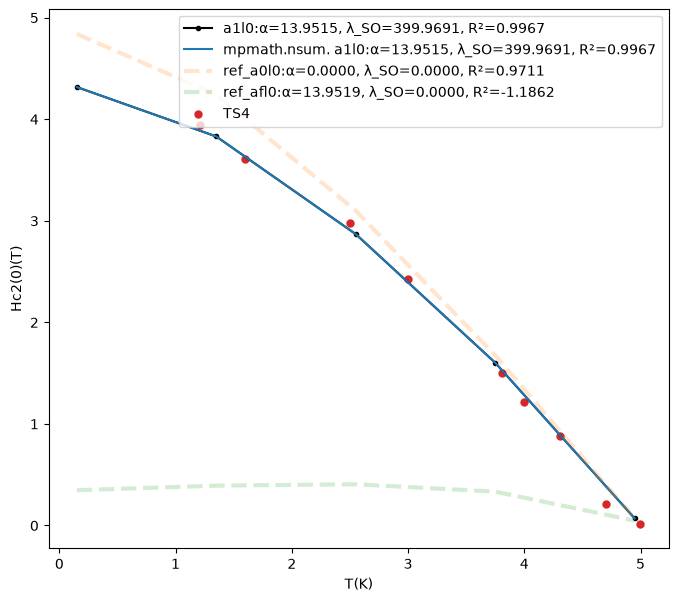

In [16]:
import matplotlib.pyplot as plt
# matplotlib
symbols=['*', '+', 'p', '.', '1','o','p','s','x']
plt.figure(figsize=(8, 7))

# plot for experiments0, TS1
ci=0 #color
ei = experiments[3]

p0_id = 'a1l0'
exp_name = 'Fit_'+ei
exp_df = data_df[data_df['exp_name']==ei]

fit_df = grid_search_df[(grid_search_df['exp_name']==exp_name) & (grid_search_df['p0_name']==p0_id)]
result = mn_df[(mn_df['exp_id']==ei) & (mn_df['init_params_name']==p0_id)].iloc[0].to_dict()
fitted_params={fp:result[fp] for fp in fit}
fixed_params={fp:result[fp] for fp in fixed}
label=f"{p0_id}:α={fitted_params['alpha']:.4f}, λ_SO={fitted_params['l_so']:.4f}, R²={fit_df['r2_score'].tolist()[0]:.4f}"
plt.plot(fit_df['t'], fit_df['field'], 'k.-', label=label)


fit_df = grid_search_mpmath_df[(grid_search_mpmath_df['exp_name']==exp_name) & (grid_search_mpmath_df['p0_name']==p0_id)]
result = mn_df[(mn_df['exp_id']==ei) & (mn_df['init_params_name']==p0_id)].iloc[0].to_dict()
fitted_params={fp:result[fp] for fp in fit}
fixed_params={fp:result[fp] for fp in fixed}
label=f"mpmath.nsum. {p0_id}:α={fitted_params['alpha']:.4f}, λ_SO={fitted_params['l_so']:.4f}, R²={fit_df['r2_score'].tolist()[0]:.4f}"
plt.plot(fit_df['t'], fit_df['field'], f'C{ci}', label=label)
ci+=1

# reference lines
for j, p0_id in enumerate(['ref_a0l0', 'ref_afl0']):
    fit_meta = grid_search_df[(grid_search_df['exp_name']==exp_name) & (grid_search_df['p0_name']==p0_id)].iloc[0].to_dict()
    fit_df = grid_search_df[(grid_search_df['exp_name']==exp_name) & (grid_search_df['p0_name']==p0_id)]
    label=f"{p0_id}:α={fit_meta['alpha']:.4f}, λ_SO={fit_meta['l_so']:.4f}, R²={fit_meta['r2_score']:.4f}"
    plt.plot(fit_df['t'], fit_df['field'], f'C{ci}--', label=label, linewidth=3, alpha=0.2)
    ci+=1

plt.scatter(exp_df['t'], exp_df['field'], c=f'C{ci}', marker=symbols[ci], label=f"{ei}", linewidths=3)
plt.legend()
plt.xlabel('T(K)')
plt.ylabel('Hc2(0)(T)')

Text(0, 0.5, 'ΔHc2(0)(T)')

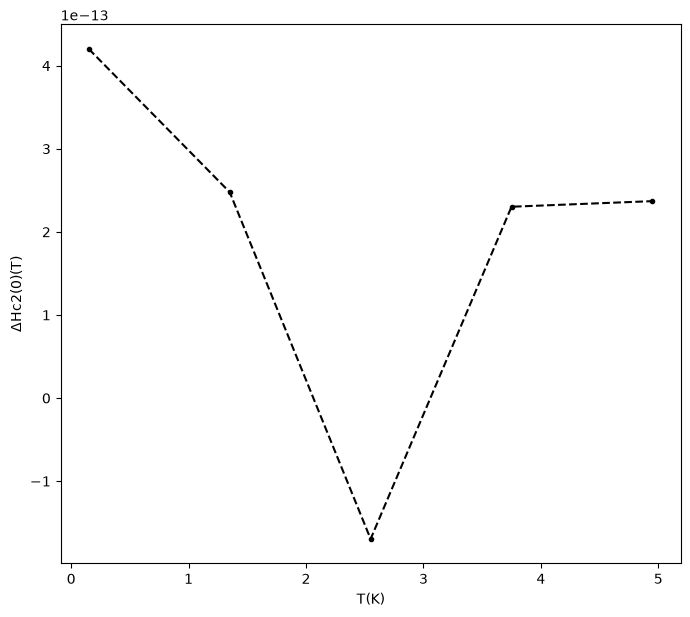

In [17]:
import matplotlib.pyplot as plt
# matplotlib
symbols=['*', '+', 'p', '.', '1','o','p','s','x']
plt.figure(figsize=(8, 7))

# plot for experiments0, TS1
ci=0 #color
ei = experiments[3]

p0_id = 'a1l0'
exp_name = 'Fit_'+ei
exp_df = data_df[data_df['exp_name']==ei]

fit_df = grid_search_df[(grid_search_df['exp_name']==exp_name) & (grid_search_df['p0_name']==p0_id)]
result = mn_df[(mn_df['exp_id']==ei) & (mn_df['init_params_name']==p0_id)].iloc[0].to_dict()
fitted_params={fp:result[fp] for fp in fit}
fixed_params={fp:result[fp] for fp in fixed}


fit_df_mpmath = grid_search_mpmath_df[(grid_search_mpmath_df['exp_name']==exp_name) & (grid_search_mpmath_df['p0_name']==p0_id)]
result = mn_df[(mn_df['exp_id']==ei) & (mn_df['init_params_name']==p0_id)].iloc[0].to_dict()
fitted_params={fp:result[fp] for fp in fit}
fixed_params={fp:result[fp] for fp in fixed}
plt.plot(fit_df['t'], fit_df['field'].to_numpy()-fit_df_mpmath['field'].to_numpy(), 'k.--')

plt.xlabel('T(K)')
plt.ylabel('ΔHc2(0)(T)')